# COE Analysis: Planning a Car Purchase

**Stakeholder:** a potential car buyer in Singapore, who needs to decide *when to buy, what to buy and how much to budget*.

This notebook uses the cleaned data from [`data-cleaning-and-exploration.ipynb`](data-cleaning-and-exploration.ipynb). Each section answers one question, first with simple methods that are easy to explain, then with regression where it adds accuracy.

| Section | Question |
|---|---|
| 1 | Preparation: quota-period table, PQP, handling gaps |
| 2 | How much can premiums move before I buy? (budget buffer) |
| 3 | Does the announced quota predict the premium? |
| 4 | When to bid? |
| 5 | How much does Category A save over B? |
| 6 | Renew or replace at year 10? |
| 7 | Alternatives to owning a car |
| 8 | Recommendations |

In [1]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 30)

DATA_DIR = '../data'
COE_CLEAN_PATH = f'{DATA_DIR}/COEBiddingResultsPrices_clean.csv'
POP_CLEAN_PATH = f'{DATA_DIR}/AnnualMotorVehiclePopulationbyVehicleType_clean.csv'
CATS = ['Category A', 'Category B', 'Category C', 'Category D', 'Category E']

In [2]:
# Chart style: same as the exploration notebook
INK, INK_2, MUTED, GRID, AXIS, SURFACE = '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#c3c2b7', '#fcfcfb'
BLUE, BLUE_LIGHT = '#2a78d6', '#b7d3f6'

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'axes.edgecolor': AXIS, 'axes.labelcolor': INK_2, 'axes.titlecolor': INK,
    'axes.titlesize': 10, 'axes.titleweight': 'bold', 'axes.titlelocation': 'left',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'axes.grid.axis': 'y', 'axes.axisbelow': True,
    'grid.color': GRID, 'grid.linewidth': 0.6,
    'xtick.color': AXIS, 'ytick.color': AXIS, 'xtick.labelcolor': INK_2, 'ytick.labelcolor': INK_2,
    'font.size': 9, 'figure.dpi': 110, 'figure.titlesize': 12, 'figure.titleweight': 'bold',
})
THOUSANDS = FuncFormatter(lambda x, _: f'{x:,.0f}')

## 1. Data Preparation

Note gaps in data:
- **April to June 2020 has no bidding** (COVID-19). Changes that span this gap are left out rather than bridged.
- **The latest data is September 2026**, so 2026 is a partial year.

**Impute the 2 blank cells for time-series work.** The clean file keeps them blank. Here, `premium_f` and `quota_f` fill each gap with the average of the exercise before and after in the same category, and `imputed` marks the rows so they can be checked or excluded.

In [3]:
# Load and clean COE data and sort by vehicle class, date, and bidding number
coe = pd.read_csv(COE_CLEAN_PATH, dtype={'quota': 'Int64', 'bids_success': 'Int64', 'bids_received': 'Int64', 'premium': 'Int64'})
coe['date'] = pd.to_datetime(coe['month'])
coe = coe.sort_values(['vehicle_class', 'date', 'bidding_no']).reset_index(drop=True)

# Impute the 2 blank cells from neighbouring exercises in the same category, and flag them
coe['imputed'] = coe['premium'].isna() | coe['quota'].isna()
for col in ['premium', 'quota']:
    coe[f'{col}_f'] = coe.groupby('vehicle_class')[col].transform(lambda s: s.astype(float).interpolate())

coe.loc[coe['imputed'], ['month', 'bidding_no', 'vehicle_class', 'quota', 'quota_f', 'premium', 'premium_f']]

,month,bidding_no,vehicle_class,quota,quota_f,premium,premium_f
398,2010-02,1,Category B,<NA>,701.0,23180,23180.0
1189,2010-01,2,Category D,378,378.0,<NA>,870.5


**Build a quota-period table.** LTA sets quotas for **February to April, May to July, August to October and November to January**, one month later than calendar quarters. The data confirms this: within these periods the quota per exercise varies by about 4% (unallocated COEs roll over), but within calendar quarters it varies by about 12%. So the quota period, not the calendar quarter, is the unit for comparing supply and price.

Periods with fewer than 6 exercises are partial and are marked `complete = False`: November 2009 to January 2010 (the data starts in January 2010), February to April and May to July 2020 (COVID-19 suspension), and August to October 2026 (the data ends in September 2026).

In [4]:
# Quota-period table per category: supply, demand and average premium.
# Shifting each date back 1 month lines LTA's quota periods up with calendar quarters,
# e.g. 2024Q1 = February to April 2024 and 2024Q4 = November 2024 to January 2025.
coe['quota_period'] = (coe['date'] - pd.DateOffset(months=1)).dt.to_period('Q')
quota_periods = coe.groupby(['vehicle_class', 'quota_period']).agg(
    exercises=('premium_f', 'size'),
    quota=('quota_f', 'sum'),
    bids_received=('bids_received', 'sum'),
    premium=('premium_f', 'mean'),
).reset_index()
quota_periods['bid_ratio'] = quota_periods['bids_received'] / quota_periods['quota']
quota_periods['complete'] = quota_periods['exercises'] == 6

print('Partial periods:')
print(quota_periods.loc[~quota_periods['complete'] & (quota_periods['vehicle_class'] == 'Category A'),
                        ['quota_period', 'exercises']].to_string(index=False))
quota_periods.tail(5).round({'premium': 0, 'bid_ratio': 2})

Partial periods:
quota_period  exercises
      2009Q4          2
      2020Q1          4
      2020Q2          2
      2026Q3          4


,vehicle_class,quota_period,exercises,quota,bids_received,premium,bid_ratio,complete
335,Category E,2025Q3,6,1550.0,2917,131958.0,1.88,True
336,Category E,2025Q4,6,1702.0,2886,121817.0,1.7,True
337,Category E,2026Q1,6,1487.0,2938,117984.0,1.98,True
338,Category E,2026Q2,6,1573.0,2801,129246.0,1.78,True
339,Category E,2026Q3,4,1077.0,1854,135222.0,1.72,False


**Estimate the PQP** (Prevailing Quota Premium), the price owners pay to renew a COE. LTA calculates it as the average premium of the previous 3 months. Here it is approximated as the average of the latest 6 exercises.

In [5]:
# Approximate PQP: average premium of the latest 6 exercises (3 months) in each category
coe['pqp'] = coe.groupby('vehicle_class')['premium_f'].transform(lambda s: s.rolling(6).mean())
coe.loc[coe['date'] == coe['date'].max(), ['month', 'bidding_no', 'vehicle_class', 'premium', 'pqp']].round(0)

,month,bidding_no,vehicle_class,premium,pqp
394,2026-09,1,Category A,133009,127374.0
395,2026-09,2,Category A,131890,128715.0
790,2026-09,1,Category B,135001,130032.0
791,2026-09,2,Category B,133000,131615.0
1186,2026-09,1,Category C,93101,92756.0
1187,2026-09,2,Category C,92144,92614.0
1582,2026-09,1,Category D,12556,10792.0
1583,2026-09,2,Category D,12201,11161.0
1978,2026-09,1,Category E,137890,132111.0
1979,2026-09,2,Category E,137000,133444.0


## 2. How much can premiums move before I buy?

A potential car buyer usually decides on a car weeks or months before bidding. As a potential car buyer, I would want to know **how much higher could the premium be by then, and how much should I budget as a buffer?**

**Approach:** 
For every exercise, compare the premium with the same exercise 1, 3, 6 and 12 months later in the same category. For example, compare 2015-03 exercise 1 with 2015-06 exercise 1. This gives about 370 to 390 past examples per category and time gap. From here, compute:
- **% of cases where premiums went up**
- the **median change** ie. the typical outcome
- the **90th and 95th percentile** to reflect a bad case. In 9 out of 10 (or 19 out of 20) past cases, the rise was no bigger than this, so it works as a **budget buffer**.
- the **5th percentile** to reflect a good case, for the downside

In [6]:
HORIZONS = [1, 3, 6, 12]  # months ahead

def premium_changes(df, months):
    """Percentage change in premium from each exercise to the same exercise `months` later, per category.
    Pairs are matched by date, so any pair that would span the April to June 2020 gap is dropped."""
    later = df[['vehicle_class', 'date', 'bidding_no', 'premium_f']].copy()
    later['date'] -= pd.DateOffset(months=months)
    pairs = df.merge(later, on=['vehicle_class', 'date', 'bidding_no'], suffixes=('', '_later'))
    return pairs.assign(months=months, change=pairs['premium_f_later'] / pairs['premium_f'] - 1)[
        ['vehicle_class', 'date', 'months', 'change']]

changes = pd.concat([premium_changes(coe, m) for m in HORIZONS], ignore_index=True)

def summarise(g):
    c = g['change']
    return pd.Series({'examples': len(c), '% went up': (c > 0).mean(), 'good case (5th pct)': c.quantile(0.05),
                      'median': c.median(), 'buffer (90th pct)': c.quantile(0.9), 'buffer (95th pct)': c.quantile(0.95)})

moves = changes.groupby(['vehicle_class', 'months']).apply(summarise)
moves.style.format({'examples': '{:.0f}', '% went up': '{:.0%}', 'good case (5th pct)': '{:+.0%}', 'median': '{:+.0%}',
                    'buffer (90th pct)': '{:+.0%}', 'buffer (95th pct)': '{:+.0%}'})

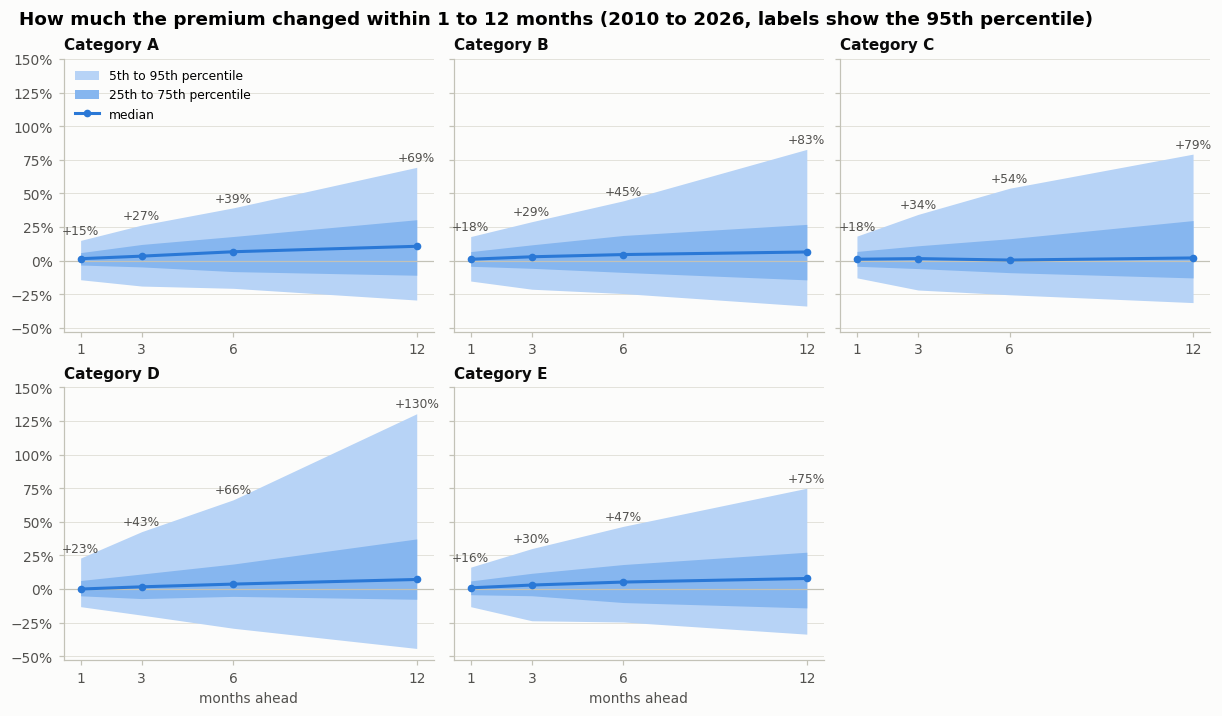

In [7]:
# Range of past outcomes by months ahead: 5th to 95th percentile (light), 25th to 75th (dark), median (line)
q = changes.groupby(['vehicle_class', 'months'])['change'].quantile([0.05, 0.25, 0.5, 0.75, 0.95]).unstack()
fig, axes = plt.subplots(2, 3, figsize=(11, 6.4), sharex=True, sharey=True, layout='constrained')
for ax, cat in zip(axes.flat, CATS):
    d = q.loc[cat]
    ax.axhline(0, color=AXIS, linewidth=0.8)
    ax.fill_between(d.index, d[0.05], d[0.95], color=BLUE_LIGHT, linewidth=0, label='5th to 95th percentile')
    ax.fill_between(d.index, d[0.25], d[0.75], color='#86b6ef', linewidth=0, label='25th to 75th percentile')
    ax.plot(d.index, d[0.5], color=BLUE, linewidth=2, marker='o', markersize=4, label='median')
    for m, v in d[0.95].items():
        ax.annotate(f'{v:+.0%}', xy=(m, v), xytext=(0, 4), textcoords='offset points', ha='center', fontsize=8, color=INK_2)
    ax.set_title(cat)
    ax.set_xticks(HORIZONS)
    ax.tick_params(labelbottom=True)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
for ax in axes[1]:
    ax.set_xlabel('months ahead')
axes.flat[-1].set_visible(False)
axes.flat[0].set_ylim(top=q[0.95].max() + 0.2)  # room for the labels
axes.flat[0].legend(frameon=False, loc='upper left', fontsize=8)
fig.suptitle('How much the premium changed within 1 to 12 months (2010 to 2026, labels show the 95th percentile)', x=0.01, ha='left')
plt.show()

- The median line across all categories stay close to 0%, and reaching about +2% (Cat D) and to +11% (Cat A) after 12 months
- Based on the widening band as months progress, there's greater uncertainty and range for premiums ie. the buffer needed grows with time. For Cat A,the 5th to 95th percentile band (where almost all outcomes fall into) is at +-15-20% for 1 month, but grows to -30%+70% at 12 months. For Cat B, the 90th percentile rise is about +14% within 1 month, +22% within 3 months, +37% within 6 months and +59% within 12 months.
- Rise in premiums are bigger than drop in premiums
- Cat D is most volatile while Cat A is more stable.

For future car owners:
If you plan to buy a Category A or B car within 3 months, budget about **20% to 25% above today's premium**. Within 6 months, about **30% to 40%** above. These cover 9 out of 10 past cases (90th percentile); use the 95th percentile for a safer margin.

Generally it makes sense to budget for the upper band. The longer the wait, the bigger the buffer. In other words, waiting doesn't pay off.

In [8]:
# Compare the % of exercises that went up and the 90th percentile of change, for all years vs since Feb 2018 (when the vehicle growth rate was set to 0%, so the policy has been the same since)
POLICY_START = '2018-02-01'
since_2018 = changes[changes['date'] >= POLICY_START]
compare = pd.concat({
    'all years: % went up': changes.groupby(['vehicle_class', 'months'])['change'].apply(lambda c: (c > 0).mean()),
    'since Feb 2018: % went up': since_2018.groupby(['vehicle_class', 'months'])['change'].apply(lambda c: (c > 0).mean()),
    'all years: 90th pct': changes.groupby(['vehicle_class', 'months'])['change'].quantile(0.9),
    'since Feb 2018: 90th pct': since_2018.groupby(['vehicle_class', 'months'])['change'].quantile(0.9),
}, axis=1)
compare.loc[(slice(None), [3, 6]), :].style.format({c: ('{:.0%}' if 'went up' in c else '{:+.0%}') for c in compare.columns})

- Premiums rise more often than they fall. Over 3 to 6 months, Categories A, B and E went up in about 60% of past cases, and in 65% to 75% of cases since February 2018, when the vehicle growth rate was set to 0%.

Let's try to apply the budget buffer to the latest premium (September 2026, exercise 2), for a buyer planning to bid in 3 or 6 months.

In [9]:
# Compare the latest premium with the typical and budget premiums 3 and 6 months later, based on the median and 90th percentile of past changes
latest = coe[coe['date'] == coe['date'].max()].groupby('vehicle_class').last()['premium_f']
example = pd.DataFrame({'latest premium': latest})
for m in [3, 6]:
    example[f'{m} months: typical'] = latest * (1 + moves.loc[(slice(None), m), 'median'].droplevel(1))
    example[f'{m} months: budget (90th pct)'] = latest * (1 + moves.loc[(slice(None), m), 'buffer (90th pct)'].droplevel(1))
example.style.format('${:,.0f}')

,latest premium,3 months: typical,3 months: budget (90th pct),6 months: typical,6 months: budget (90th pct)
vehicle_class,,,,,
Category A,"$131,890","$136,341","$158,385","$140,654","$173,572"
Category B,"$133,000","$136,846","$162,558","$139,051","$182,090"
Category C,"$92,144","$93,567","$114,908","$92,573","$127,890"
Category D,"$12,201","$12,402","$15,313","$12,650","$18,020"
Category E,"$137,000","$141,069","$166,799","$144,115","$188,386"


- Across all categories, the typical outcome is about ~$1-5K more than the latest premium.
- However, to be safe, budget at 90th percentile (10% chance of falling short). For example, for Cat A, budget ~$158K in 3 months, and ~$173K in 6 months.
  

## 3. Does the announced quota predict the premium?

LTA announces each period's quota before its first exercise. **If the quota goes up or down, what usually happens to the premium?** This matters to a buyer deciding whether to bid now or wait for the next period, and to the policymaker as a measure of how strongly supply moves price.

**Approach 1 (simple):** compare each complete quota period with the one before it. Group the periods into *quota down by more than 10%*, *within ±10%* and *up by more than 10%*, and look at how the average premium changed in each group.

**Approach 2 (regression):** fit a line through all period-to-period changes, in each category. The **slope** says how much the premium changes, on average, for a given change in quota. Three details:
- Changes are measured as **log changes**, which are close to % changes for small moves and treat rises and falls evenly. A slope of −0.25 means a 10% quota cut goes with about a 2.7% higher premium.
- Periods next to each other can be similar, which makes ordinary error estimates too confident. The **p-value** and **95% range** use a correction for this (HAC standard errors).
- A **robust check** refits the line while giving less weight to extreme periods, to see if a few unusual periods drive the result.

Only pairs of back-to-back complete periods are used, so the partial periods around 2020 and the latest period are left out.

In [10]:
# Change from each complete quota period to the next, per category (log changes, about equal to % changes)
qp = quota_periods[quota_periods['complete']].sort_values(['vehicle_class', 'quota_period']).copy()
qp['back_to_back'] = qp.groupby('vehicle_class')['quota_period'].diff().apply(lambda x: getattr(x, 'n', None)) == 1
for col in ['quota', 'premium']:
    qp[f'{col}_change'] = np.log(qp[col]).groupby(qp['vehicle_class']).diff()
qp = qp[qp['back_to_back']].copy()
qp['quota_band'] = pd.cut(np.expm1(qp['quota_change']), [-1, -0.1, 0.1, np.inf],
                          labels=['quota down >10%', 'quota within ±10%', 'quota up >10%'])
print('Period-to-period changes per category:', qp.groupby('vehicle_class').size().iloc[0])

Period-to-period changes per category: 62


In [11]:
# Approach 1: premium change by size of quota change
bands = qp.groupby(['vehicle_class', 'quota_band'], observed=True)['premium_change'].agg(
    periods='size',
    **{'median premium change': lambda s: np.expm1(s.median()), '% premium went up': lambda s: (s > 0).mean()})
bands.style.format({'periods': '{:.0f}', 'median premium change': '{:+.1%}', '% premium went up': '{:.0%}'})

- When the quota fell by more than 10%, the premium rose in 78% to 91% of periods, with a median rise of +5.5% (B) to +10.9% (D).
- When the quota stayed within ±10%, the premium rose in 55% to 65% of periods (median about +2% to +3%). This is the general upward drift.
- When the quota rose by more than 10%, the premium did not reliably fall. For B, C and D it rose in only 25% to 40% of periods. For A (median +1.5%, rose in 56%) and E (median −0.6%, rose in 42%), a bigger quota made little difference.

In [12]:
# Approach 2: regression of premium change on quota change, per category
fits, rows = {}, {}
for cat, g in qp.groupby('vehicle_class'):
    ols = smf.ols('premium_change ~ quota_change', g).fit(cov_type='HAC', cov_kwds={'maxlags': 2})
    robust = sm.RLM(g['premium_change'], sm.add_constant(g['quota_change']), M=sm.robust.norms.HuberT()).fit()
    low, high = ols.conf_int().loc['quota_change']
    slope = ols.params['quota_change']
    fits[cat] = ols
    rows[cat] = {'periods': int(ols.nobs), 'slope': slope, '95% range: low': low, '95% range: high': high,
                 'p-value': ols.pvalues['quota_change'], 'R²': ols.rsquared,
                 'premium change if quota 10% lower': 0.9 ** slope - 1,
                 'slope (robust check)': robust.params['quota_change']}
reg = pd.DataFrame(rows).T
reg.style.format({'periods': '{:.0f}', 'slope': '{:.2f}', '95% range: low': '{:.2f}', '95% range: high': '{:.2f}',
                  'p-value': '{:.4f}', 'R²': '{:.2f}', 'premium change if quota 10% lower': '{:+.1%}',
                  'slope (robust check)': '{:.2f}'})

,periods,slope,95% range: low,95% range: high,p-value,R²,premium change if quota 10% lower,slope (robust check)
Category A,62,-0.24,-0.36,-0.12,0.0001,0.14,+2.5%,-0.23
Category B,62,-0.26,-0.52,-0.00,0.0492,0.07,+2.8%,-0.30
Category C,62,-0.15,-0.20,-0.10,0.0000,0.21,+1.6%,-0.15
Category D,62,-0.78,-1.14,-0.42,0.0000,0.41,+8.5%,-0.66
Category E,62,-0.25,-0.39,-0.11,0.0004,0.13,+2.7%,-0.24


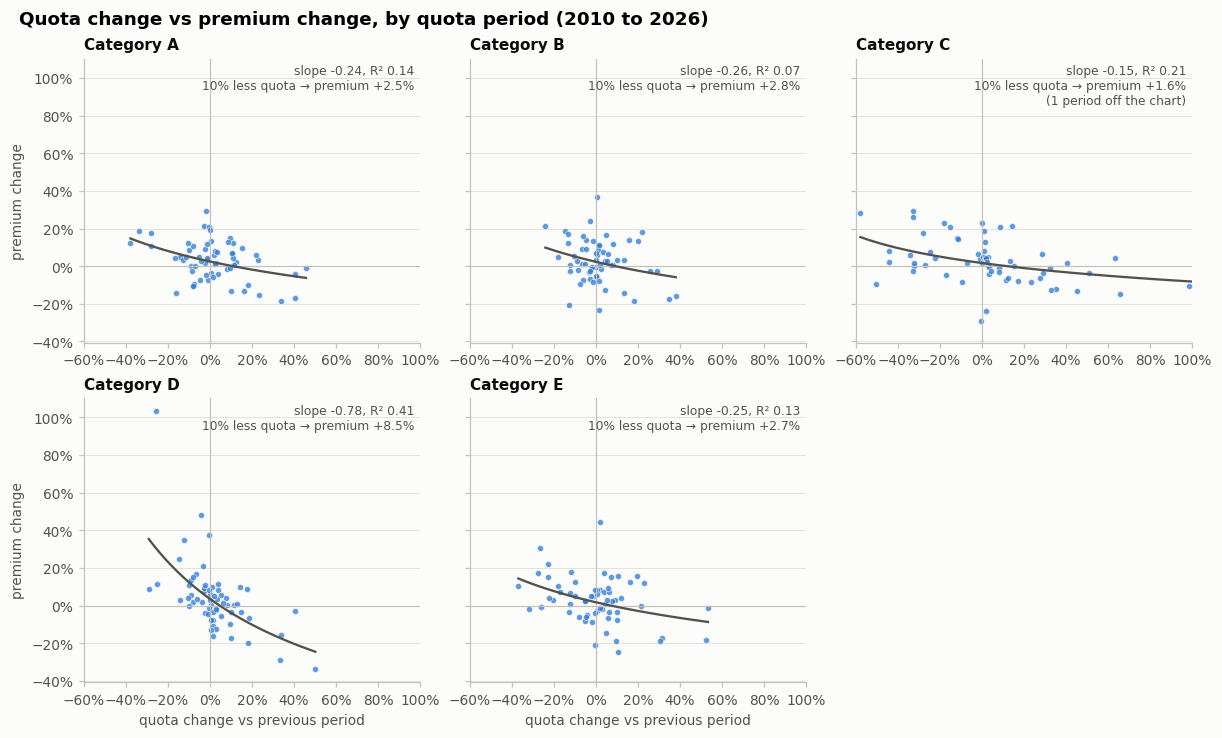

In [13]:
# Each dot is one quota period compared with the one before; the line is the regression fit
XLIM = (-0.6, 1.0)
fig, axes = plt.subplots(2, 3, figsize=(11, 6.6), sharex=True, sharey=True, layout='constrained')
for ax, cat in zip(axes.flat, CATS):
    g = qp[qp['vehicle_class'] == cat]
    x, y = np.expm1(g['quota_change']), np.expm1(g['premium_change'])
    ax.axhline(0, color=AXIS, linewidth=0.8)
    ax.axvline(0, color=AXIS, linewidth=0.8)
    ax.scatter(x, y, s=16, color=BLUE, alpha=0.75, edgecolor=SURFACE, linewidth=0.5)
    grid = np.linspace(max(x.min(), XLIM[0]), min(x.max(), XLIM[1]), 100)  # fit only over the observed range
    a, b = fits[cat].params['Intercept'], fits[cat].params['quota_change']
    ax.plot(grid, np.expm1(a + b * np.log1p(grid)), color=INK_2, linewidth=1.5)
    note = f'slope {b:.2f}, R² {fits[cat].rsquared:.2f}\n10% less quota → premium {0.9 ** b - 1:+.1%}'
    outside = int(((x < XLIM[0]) | (x > XLIM[1])).sum())
    if outside:
        note += f'\n({outside} period{"s" if outside > 1 else ""} off the chart)'
    ax.annotate(note, xy=(1, 1), xycoords='axes fraction', xytext=(-4, -4), textcoords='offset points',
                ha='right', va='top', fontsize=8, color=INK_2)
    ax.set_title(cat)
    ax.set_xlim(XLIM)
    ax.xaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
    ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
    ax.tick_params(labelbottom=True)
for ax in axes[1]:
    ax.set_xlabel('quota change vs previous period')
for ax in axes[:, 0]:
    ax.set_ylabel('premium change')
axes.flat[-1].set_visible(False)
fig.suptitle('Quota change vs premium change, by quota period (2010 to 2026)', x=0.01, ha='left')
plt.show()

- All five slopes are negative with p-values below 0.05. **A 10% quota cut goes with a premium about 2.5% to 2.8% higher for A, B and E**, 1.6% higher for C and 8.5% higher for D, in the same period.
- Quota explains only a small part of the move. R² is 0.07 (B) to 0.21 (C) and 0.41 for D. Most period-to-period changes in car premiums come from demand (the economy, buyer sentiment, dealer and fleet bidding), not supply.
- The two approaches agree: quota cuts push premiums up; quota increases help less than expected.

**For a buyer:**
- Check the announced quota before deciding when to bid. A cut of more than 10% is a warning: in about 8 or 9 out of 10 such periods, the premium was higher than in the period before. If you are ready, bidding before the cut takes effect has usually been cheaper.
- A quota increase is not a reliable reason to wait, especially for Categories A and E.
- For motorcycles (D), the quota matters much more: a 10% change goes with about an 8.5% change in premium.

**For the policymaker:** 
- The quota is a real but **limited lever** for cars. A 10% change in supply goes with only about a 2.5% to 3% change in the car premium, and explains a small share of its movement. Changing supply alone will not bring car premiums down much.

**Limitations:** 
- While this shows how premiums moved alongside quota changes in the same period, it is not proof that the quota alone caused them. Quotas are largely set from recent deregistrations, which may also relate to demand.

## 4. When to bid?

Does it pay to bid at a particular time? Three checks, each with a simple comparison and a statistical test:
1. **First vs second exercise of the month.** Compare the two exercises in the same month.
2. **Position in the quota period.** The quota is set for the whole period, so is the first, second or third month of a period cheaper?
3. **Month of the year.** Is there a seasonal pattern, for example around Chinese New Year or the year end?

For checks 2 and 3, premiums have long-term trends that would hide any seasonal effect. So each month's average premium is compared with a **trend line** (a centred 12-month moving average). A value of −3% means that month was 3% below the trend around it.

The tests give a **p-value**: the chance of seeing a pattern at least this large if timing made no real difference. Below 0.05 is usually treated as a real pattern. Even a real pattern only matters if it is large compared with the normal ups and downs from one exercise to the next.

In [14]:
# Check 1: second exercise vs first exercise in the same month
pair = coe.pivot_table(index=['vehicle_class', 'month'], columns='bidding_no', values='premium_f')
pair['change'] = pair[2] / pair[1] - 1
ex = pair.groupby(level='vehicle_class')['change'].agg(
    months='size', median='median',
    **{'% exercise 2 higher': lambda s: (s > 0).mean(), '10th pct': lambda s: s.quantile(0.1),
       '90th pct': lambda s: s.quantile(0.9), 'p-value': lambda s: stats.wilcoxon(s).pvalue})
ex.style.format({'months': '{:.0f}', 'median': '{:+.1%}', '% exercise 2 higher': '{:.0%}',
                 '10th pct': '{:+.1%}', '90th pct': '{:+.1%}', 'p-value': '{:.3f}'})

,months,median,% exercise 2 higher,10th pct,90th pct,p-value
vehicle_class,,,,,,
Category A,198,+1.0%,56%,-7.9%,+8.5%,0.119
Category B,198,+0.7%,57%,-6.8%,+9.7%,0.029
Category C,198,+0.3%,54%,-5.7%,+6.5%,0.164
Category D,198,+0.0%,51%,-8.0%,+8.2%,0.609
Category E,198,+0.9%,62%,-5.0%,+8.1%,0.003


- The 2nd exercise's premium is higher by a median of only 0.0% to 1.0%, and higher in 51% to 62% of months. The difference is statistically detectable for B (p = 0.03) and E (p = 0.003), but tiny compared with the normal swing between the two exercises (10th to 90th percentile about −7% to +9%). - It most likely reflects the general upward drift over two weeks, not something special about the second exercise.

In [15]:
# Monthly average premium compared with its trend (centred 2x12 moving average), per category
monthly = coe.groupby(['date', 'vehicle_class'])['premium_f'].mean().unstack()
monthly = monthly.reindex(pd.date_range(monthly.index.min(), monthly.index.max(), freq='MS'))  # keeps the 2020 gap as blanks
trend = monthly.rolling(12, center=True).mean().rolling(2).mean()
season = ((monthly / trend - 1).rename_axis('date').reset_index()
          .melt(id_vars='date', var_name='vehicle_class', value_name='vs_trend').dropna())
season['month_of_year'] = season['date'].dt.month
season['month_of_period'] = (season['date'].dt.month - 2) % 3 + 1  # 1 = Feb, May, Aug, Nov

# Checks 2 and 3: does the month explain any of the difference from trend? (F-test p-value)
tests = pd.DataFrame({cat: {
    'months': len(g),
    'p-value: month of quota period': smf.ols('vs_trend ~ C(month_of_period)', g).fit().f_pvalue,
    'p-value: month of year': smf.ols('vs_trend ~ C(month_of_year)', g).fit().f_pvalue,
} for cat, g in season.groupby('vehicle_class')}).T
by_period_month = season.groupby(['vehicle_class', 'month_of_period'])['vs_trend'].median().unstack()
by_period_month.columns = [f'median vs trend: month {m} of period' for m in by_period_month.columns]
tests.join(by_period_month).style.format('{:+.1%}', subset=list(by_period_month.columns)).format(
    '{:.3f}', subset=['p-value: month of quota period', 'p-value: month of year']).format('{:.0f}', subset=['months'])

,months,p-value: month of quota period,p-value: month of year,median vs trend: month 1 of period,median vs trend: month 2 of period,median vs trend: month 3 of period
Category A,174,0.982,0.392,+1.3%,-0.0%,+0.0%
Category B,174,0.844,0.445,+0.4%,-0.2%,-1.0%
Category C,174,0.905,0.004,-1.3%,+1.2%,-1.5%
Category D,174,0.518,0.000,-1.0%,+0.2%,+1.2%
Category E,174,0.764,0.332,+0.1%,+0.0%,-0.7%


- Month of the quota period: no pattern in any category (p-values 0.52 to 0.98). The first, second and third months are all within ±1.5% of trend.


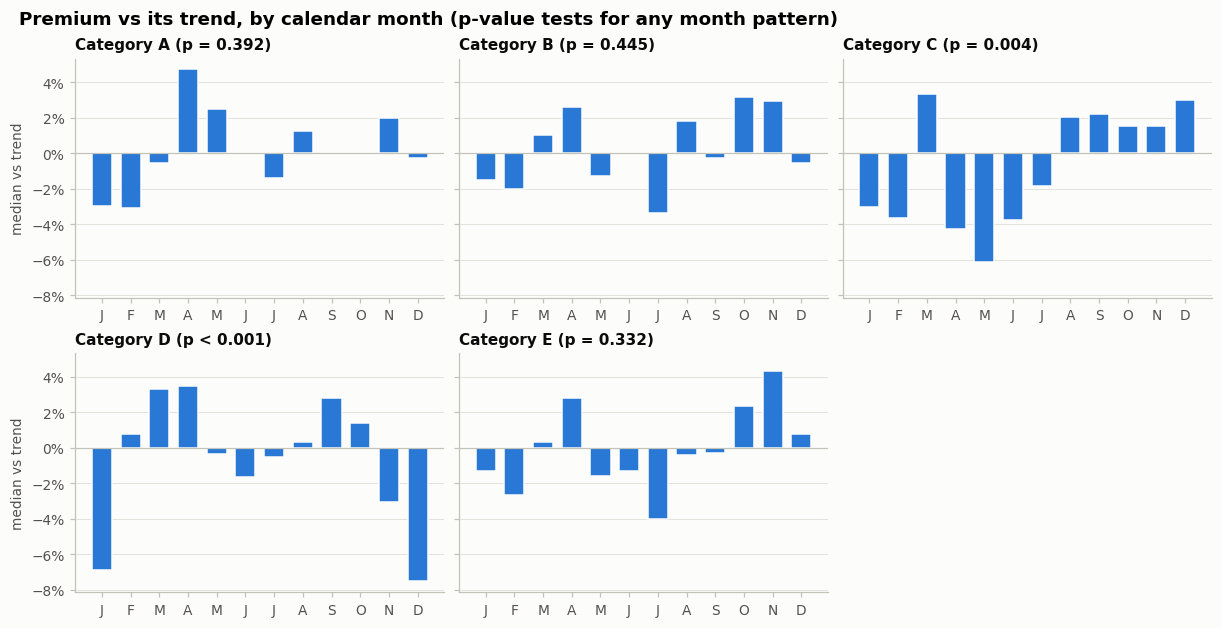

In [16]:
# Median difference from trend by calendar month
MONTHS = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
med = season.groupby(['vehicle_class', 'month_of_year'])['vs_trend'].median().unstack(0)
fig, axes = plt.subplots(2, 3, figsize=(11, 5.6), sharex=True, sharey=True, layout='constrained')
for ax, cat in zip(axes.flat, CATS):
    ax.axhline(0, color=AXIS, linewidth=0.8)
    ax.bar(med.index, med[cat], color=BLUE, width=0.7, edgecolor=SURFACE, linewidth=1)
    pv = tests.loc[cat, 'p-value: month of year']
    ax.set_title(f"{cat} (p {'< 0.001' if pv < 0.001 else f'= {pv:.3f}'})")
    ax.set_xticks(range(1, 13), [m[0] for m in MONTHS])
    ax.tick_params(labelbottom=True)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
for ax in axes[:, 0]:
    ax.set_ylabel('median vs trend')
axes.flat[-1].set_visible(False)
fig.suptitle('Premium vs its trend, by calendar month (p-value tests for any month pattern)', x=0.01, ha='left')
plt.show()

- Month of the year: no pattern for the car categories A, B and E (p-values 0.33 to 0.45). Categories C (p = 0.004) and D (p < 0.001) show one: **motorcycle (D) premiums are about 7% below trend in December and January**, and C is lowest from April to June (−4% to −6%).
- Note: each calendar month has only about 14 years of data, and 15 tests were run in this section, so one "significant" result could appear by chance. D's pattern is strong enough to note, but it is not guaranteed to repeat.

**For a buyer:**
- **For cars (A, B, E), timing makes no reliable difference**: not the exercise, not the month of the quota period, not the month of the year. Bid when you are ready, and focus on the budget buffer (Section 2) and the quota signal (Section 3).
- **For motorcycles, December and January have been about 7% below trend**, a possible but not guaranteed saving of roughly $850 at today's premium of about $12,000.

The simple comparisons and the statistical tests agree.

## 5. How much does Category A save over B?

Category A covers smaller cars (up to 1,600cc and 97kW, or 110kW for electric cars). Category B covers the rest. **How much cheaper is a Category A COE, and is the saving stable?**

**Approach 1 (simple):** in every exercise, compare the two premiums: the gap in dollars and as a % of the Category A premium. Look at the gap over time and across three periods split by rule changes:
- **February 2014:** the 97kW engine power limit was added to Category A, which moved more powerful small-engine cars into B.
- **May 2022:** the limit for electric cars in Category A was raised to 110kW.

**Approach 2 (regression):** test whether the average gap (measured as a log ratio of B to A) differs between the three periods, with the same correction for nearby exercises being similar (HAC standard errors).

This compares COE premiums only. Category B cars usually also cost more to buy.

In [17]:
# Gap between Category B and Category A premiums in the same exercise
ab = coe.pivot_table(index=['date', 'bidding_no'], columns='vehicle_class', values='premium_f')[['Category A', 'Category B']].reset_index()
ab['gap'] = ab['Category B'] - ab['Category A']
ab['gap_pct'] = ab['Category B'] / ab['Category A'] - 1
ab['rule_period'] = pd.cut(ab['date'], [pd.Timestamp('2000-01-01'), pd.Timestamp('2014-02-01'), pd.Timestamp('2022-05-01'), pd.Timestamp('2100-01-01')],
                           right=False, labels=['Jan 2010 to Jan 2014', 'Feb 2014 to Apr 2022 (97kW limit)', 'May 2022 on (EV limit 110kW)'])

def gap_summary(g):
    return pd.Series({'exercises': len(g), 'A cheaper': (g['gap'] > 0).mean(), 'median gap ($)': g['gap'].median(),
                      'median gap (%)': g['gap_pct'].median(), '10th pct gap ($)': g['gap'].quantile(0.1),
                      '90th pct gap ($)': g['gap'].quantile(0.9)})

gaps = pd.concat([ab.groupby('rule_period', observed=True).apply(gap_summary),
                  gap_summary(ab).rename('All exercises').to_frame().T])
gaps.style.format({'exercises': '{:.0f}', 'A cheaper': '{:.0%}', 'median gap ($)': '${:,.0f}', 'median gap (%)': '{:+.0%}',
                   '10th pct gap ($)': '${:,.0f}', '90th pct gap ($)': '${:,.0f}'})

,exercises,A cheaper,median gap ($),median gap (%),10th pct gap ($),90th pct gap ($)
Jan 2010 to Jan 2014,98,95%,"$11,873",+27%,"$2,293","$23,207"
Feb 2014 to Apr 2022 (97kW limit),192,93%,"$5,320",+11%,$891,"$14,275"
May 2022 on (EV limit 110kW),106,97%,"$18,198",+18%,"$3,784","$29,355"
All exercises,396,95%,"$9,010",+16%,"$1,599","$24,697"


- Cat A has been cheaper in about 95% of the exercises by about a median of $9K.

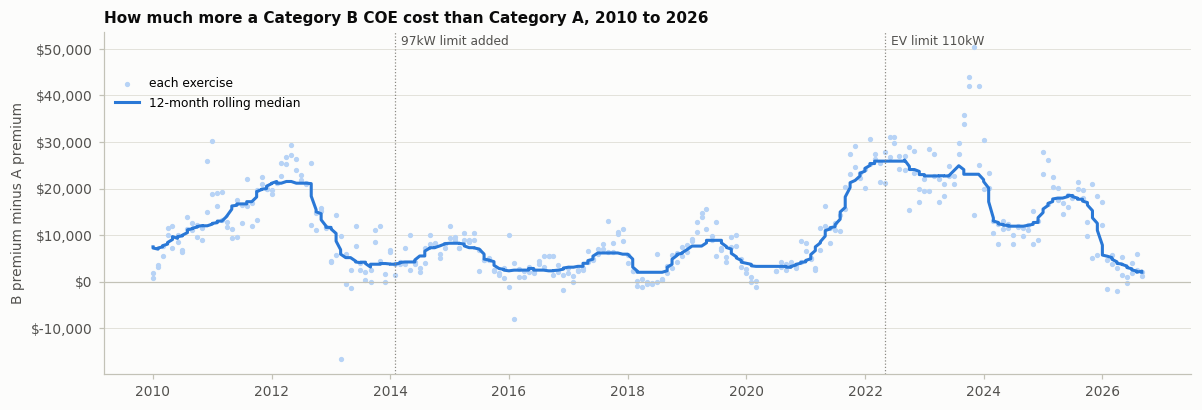

In [18]:
# Gap over time: each exercise (light) and the 12-month rolling median (line)
ab = ab.sort_values(['date', 'bidding_no'])
roll = ab.set_index('date')['gap'].rolling(24, center=True, min_periods=12).median()  # 24 exercises = 12 months
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.axhline(0, color=AXIS, linewidth=0.8)
ax.scatter(ab['date'], ab['gap'], s=6, color=BLUE_LIGHT, label='each exercise')
ax.plot(roll.index, roll.values, color=BLUE, linewidth=2, label='12-month rolling median')
for when, label in [('2014-02-01', '97kW limit added'), ('2022-05-01', 'EV limit 110kW')]:
    ax.axvline(pd.Timestamp(when), color=MUTED, linewidth=0.8, linestyle=':')
    ax.annotate(label, xy=(pd.Timestamp(when), 1), xycoords=('data', 'axes fraction'), xytext=(4, -2),
                textcoords='offset points', va='top', fontsize=8, color=INK_2)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_ylabel('B premium minus A premium')
ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(0, 0.9), fontsize=8)
ax.set_title('How much more a Category B COE cost than Category A, 2010 to 2026')
fig.tight_layout()
plt.show()

- Currently the gap has almost closed to ~$1K in Sep 2026.

In [19]:
# Approach 2: does the average gap differ between the rule periods? (log ratio of B to A; HAC standard errors)
ab['log_ratio'] = np.log(ab['Category B'] / ab['Category A'])
gap_fit = smf.ols('log_ratio ~ C(rule_period)', ab).fit(cov_type='HAC', cov_kwds={'maxlags': 12})
base = gap_fit.params['Intercept']
gap_reg = pd.DataFrame({
    'average gap (%)': [np.expm1(base)] + [np.expm1(base + gap_fit.params[k]) for k in gap_fit.params.index[1:]],
    'p-value vs Jan 2010 to Jan 2014': [np.nan] + list(gap_fit.pvalues.iloc[1:]),
}, index=ab['rule_period'].cat.categories)
gap_reg.style.format({'average gap (%)': '{:+.0%}', 'p-value vs Jan 2010 to Jan 2014': '{:.3f}'}, na_rep='–')

,average gap (%),p-value vs Jan 2010 to Jan 2014
Jan 2010 to Jan 2014,+25%,–
Feb 2014 to Apr 2022 (97kW limit),+14%,0.062
May 2022 on (EV limit 110kW),+19%,0.320


- The average gap was 25% before February 2014, 14% from February 2014 to April 2022, and 19% from May 2022. Neither difference is statistically clear (p = 0.06 and 0.32), so the rule changes did not clearly change the gap. Most of the movement follows the premium cycle.



**For a buyer:**
- **Check the current A vs B gap before choosing a car.** Over the long run, choosing a car that qualifies for Category A has saved about $9,000 on the COE, but today the saving is close to zero.
- The COE is only part of the difference: Category B cars usually cost more to buy as well.

## 6. Renew or replace at year 10?

When a COE reaches 10 years, the owner can [renew it](https://onemotoring.lta.gov.sg/content/onemotoring/home/owning/coe-renewal.html) instead of buying a new car:
- **10-year renewal:** pay 100% of the PQP. Can be renewed again later.
- **5-year renewal:** pay 50% of the PQP. Cannot be renewed again; the car must be deregistered after 5 years.

The PQP is the average premium of the previous 3 months, so it **lags** the current premium. **How often is renewing cheaper than buying a new COE, and by how much?**

**Approach:** compare the estimated PQP (from Section 1) with the premium in the same exercise, across all exercises. Split by whether premiums were rising or falling (premium vs 3 months earlier). No regression is needed: the PQP is an average of past premiums, so how it compares with the current premium follows directly from the recent trend.

This compares the COE part only. Replacing also means buying a new car, and renewing means keeping an older car, with its repair costs and no PARF rebate when it is scrapped.

In [20]:
# Renewal price (estimated PQP) vs a new COE (current premium), per exercise
renew = coe.dropna(subset=['pqp']).copy()
renew['pqp_vs_premium'] = renew['pqp'] / renew['premium_f'] - 1
renew['trend'] = np.where(renew.groupby('vehicle_class')['premium_f'].pct_change(6) > 0,
                          'premium rising (vs 3 months earlier)', 'premium falling')

def renew_summary(s):
    return pd.Series({'exercises': len(s), 'renewing cheaper': (s < 0).mean(), 'median PQP vs premium': s.median(),
                      '10th pct': s.quantile(0.1), '90th pct': s.quantile(0.9)})

renew_table = pd.concat({
    'all exercises': renew.groupby('vehicle_class')['pqp_vs_premium'].apply(renew_summary).unstack(),
    'premium rising': renew[renew['trend'].str.startswith('premium rising')].groupby('vehicle_class')['pqp_vs_premium'].apply(renew_summary).unstack(),
    'premium falling': renew[renew['trend'] == 'premium falling'].groupby('vehicle_class')['pqp_vs_premium'].apply(renew_summary).unstack(),
})
renew_table.style.format({'exercises': '{:.0f}', 'renewing cheaper': '{:.0%}', 'median PQP vs premium': '{:+.1%}',
                          '10th pct': '{:+.1%}', '90th pct': '{:+.1%}'})

- Overall, renewing is only slightly cheaper than a new COE. The PQP was lower in 55% to 58% of exercises, by a median of about 1%.
- It depends on the recent trend. When premiums had been rising, renewing was cheaper in about 80% of cases (median about 4% cheaper). When premiums had been falling, a new COE was cheaper in about 75% of cases (the PQP was a median 2.5% to 3.7% higher).

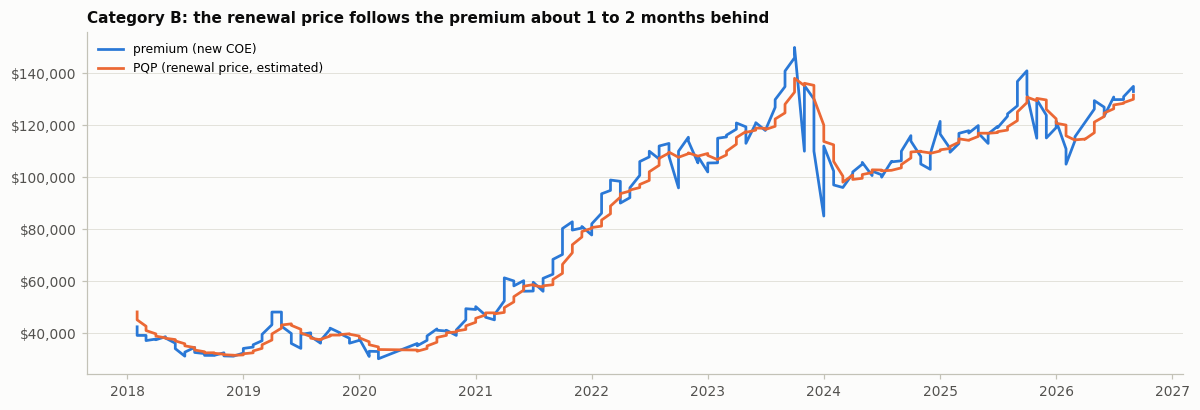

In [21]:
# The PQP lags the premium: Category B since February 2018
ORANGE, AQUA = '#eb6834', '#1baf7a'
b = coe[(coe['vehicle_class'] == 'Category B') & (coe['date'] >= POLICY_START)]
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(b['date'], b['premium_f'], color=BLUE, linewidth=1.8, label='premium (new COE)')
ax.plot(b['date'], b['pqp'], color=ORANGE, linewidth=1.8, label='PQP (renewal price, estimated)')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(frameon=False, loc='upper left', fontsize=8)
ax.set_title('Category B: the renewal price follows the premium about 1 to 2 months behind')
fig.tight_layout()
plt.show()

- Overall, renewing is only slightly cheaper than a new COE. The PQP was lower in 55% to 58% of exercises, by a median of about 1%.
- It depends on the recent trend. When premiums had been rising, renewing was cheaper in about 80% of cases (median about 4% cheaper). When premiums had been falling, a new COE was cheaper in about 75% of cases (the PQP was a median 2.5% to 3.7% higher).

In [22]:
# Latest renewal costs compared with a new COE, and the cost per year of each option
latest_rows = coe[coe['date'] == coe['date'].max()].groupby('vehicle_class').last()
renew_now = pd.DataFrame({
    'new COE (premium)': latest_rows['premium_f'],
    '10-year renewal (PQP)': latest_rows['pqp'],
    '5-year renewal (50% PQP)': latest_rows['pqp'] * 0.5,
})
renew_now['renewal vs new COE'] = renew_now['10-year renewal (PQP)'] / renew_now['new COE (premium)'] - 1
renew_now['per year: new COE or 10-year renewal'] = renew_now['10-year renewal (PQP)'] / 10
renew_now['per year: 5-year renewal'] = renew_now['5-year renewal (50% PQP)'] / 5
renew_now.style.format('${:,.0f}').format('{:+.1%}', subset=['renewal vs new COE'])

,new COE (premium),10-year renewal (PQP),5-year renewal (50% PQP),renewal vs new COE,per year: new COE or 10-year renewal,per year: 5-year renewal
vehicle_class,,,,,,
Category A,"$131,890","$128,715","$64,358",-2.4%,"$12,872","$12,872"
Category B,"$133,000","$131,615","$65,808",-1.0%,"$13,162","$13,162"
Category C,"$92,144","$92,614","$46,307",+0.5%,"$9,261","$9,261"
Category D,"$12,201","$11,161","$5,580",-8.5%,"$1,116","$1,116"
Category E,"$137,000","$133,444","$66,722",-2.6%,"$13,344","$13,344"


- Today premiums are rising, so renewing is cheaper: for Category B, a 10-year renewal costs about $131,600 against a new COE at $133,000. For motorcycles (D) it is 8.5% cheaper.
- The 5-year and 10-year renewals cost the same per year (50% of the PQP for 5 years, or 100% for 10 years). The 5-year option simply means a smaller payment, with no option to renew again.

**For a car owner at year 10:**
- The COE part of the decision is small: renewing and replacing usually differ by only a few percent. The bigger factors are the car's condition, repair costs and the price of a new car.
- If premiums have been rising, renewing usually saves a little on the COE. If they have been falling, buying a new COE is usually a little cheaper.
- Choose 5 or 10 years based on how long you want to keep the car, not on cost per year.

---
## 7. Alternatives to owning a car

With premiums above $130,000, is owning a car still the obvious choice? The population data (2005 to 2024) cannot show costs, but it shows how people's choices have shifted:
- **Private cars:** owned for personal use.
- **Private Hire (Self-Drive) cars:** rental and car-sharing cars (for example GetGo and Tribecar), driven by the person renting. This type starts in 2013, when it replaced *Rental cars*.
- **Off-peak cars:** cheaper to own, but only allowed on the roads on weekday evenings, weekends and public holidays.

**Approach:** compare how these types changed since 2013 with the Category A premium, and turn today's premium into a yearly and monthly cost, to compare with renting or car-sharing prices (which are not in these datasets).

In [23]:
pop = pd.read_csv(POP_CLEAN_PATH)
TYPES = ['Private cars', 'Private Hire (Self-Drive) cars', 'Off peak cars']
alt = pop[pop['type'].isin(TYPES)].pivot_table(index='year', columns='type', values='number')[TYPES].loc[2013:]
alt['Category A premium (yearly average)'] = coe[coe['vehicle_class'] == 'Category A'].groupby(coe['date'].dt.year)['premium_f'].mean()
alt.style.format('{:,.0f}')

type,Private cars,Private Hire (Self-Drive) cars,Off peak cars,Category A premium (yearly average)
year,,,,
2013,"540,063","15,782","42,233","74,690"
2014,"536,882","17,238","38,146","67,675"
2015,"519,645","18,884","30,469","60,601"
2016,"504,160","19,374","22,562","49,587"
2017,"502,187","21,180","16,947","45,991"
2018,"509,302","21,138","14,028","33,038"
2019,"515,036","21,566","12,977","29,907"
2020,"519,132","21,351","12,028","35,404"
2021,"532,204","23,147","11,033","47,425"


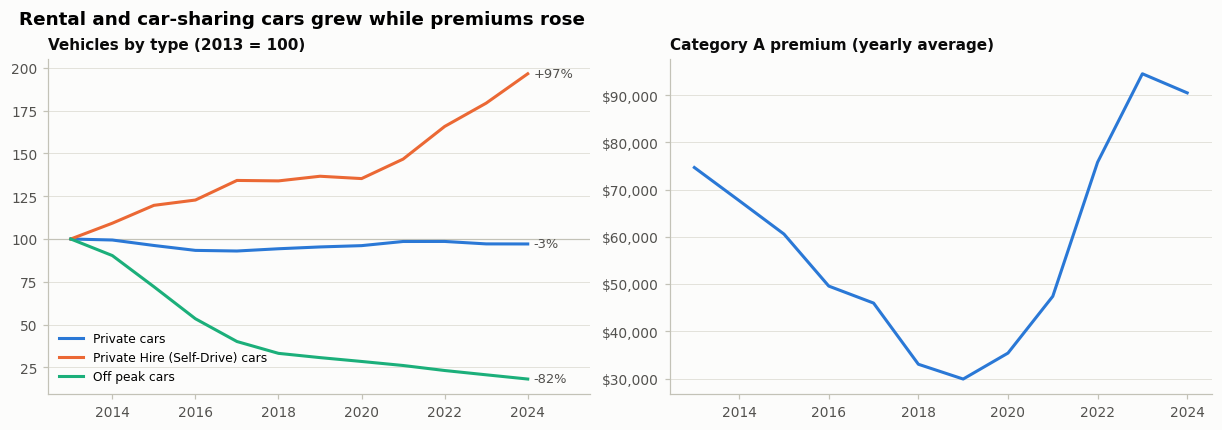

In [24]:
# Left: vehicles by type (2013 = 100). Right: Category A premium. Two panels, because the units differ.
ORANGE, AQUA = '#eb6834', '#1baf7a'
idx = alt[TYPES] / alt[TYPES].iloc[0] * 100
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8), layout='constrained')
ax1.axhline(100, color=AXIS, linewidth=0.8)
for col, color, dy in zip(TYPES, [BLUE, ORANGE, AQUA], [0, 0, 0]):
    ax1.plot(idx.index, idx[col], color=color, linewidth=2, label=col)
    ax1.annotate(f'{idx[col].iloc[-1] - 100:+.0f}%', xy=(idx.index[-1], idx[col].iloc[-1]), xytext=(4, dy),
                 textcoords='offset points', va='center', fontsize=8.5, color=INK_2)
ax1.set_xlim(right=idx.index[-1] + 1.5)
ax1.legend(frameon=False, loc='lower left', fontsize=8)
ax1.set_title('Vehicles by type (2013 = 100)')
ax2.plot(alt.index, alt['Category A premium (yearly average)'], color=BLUE, linewidth=2)
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.set_title('Category A premium (yearly average)')
fig.suptitle('Rental and car-sharing cars grew while premiums rose', x=0.01, ha='left')
plt.show()

- Rental and car-sharing cars (Private Hire Self-Drive) almost doubled from 2013 to 2024 (+97%), and grew fastest after 2021 (+34%), when the Category A premium roughly doubled.
- Private cars stayed almost flat (−3%), and off-peak cars fell by 82%. Off-peak cars are no longer a common way to own a car more cheaply.

In [25]:
# The COE alone, spread over its 10 years
coe_cost = latest.rename('latest premium').to_frame()
coe_cost['per year'] = coe_cost['latest premium'] / 10
coe_cost['per month'] = coe_cost['latest premium'] / 120
coe_cost.style.format('${:,.0f}')

,latest premium,per year,per month
vehicle_class,,,
Category A,"$131,890","$13,189","$1,099"
Category B,"$133,000","$13,300","$1,108"
Category C,"$92,144","$9,214",$768
Category D,"$12,201","$1,220",$102
Category E,"$137,000","$13,700","$1,142"


- The COE alone now costs about $13,000 a year, or $1,100 a month, for a Category A or B car, before the car itself, road tax, insurance, parking and fuel.

**For a buyer:**
- If driving only occasionally, compare the monthly cost of owning (COE of about $1,100 a month plus the car and running costs) with renting or car-sharing for the trips you actually make.
- The growth of rental and car-sharing fleets shows that **more people are choosing to use cars without owning them**. The data shows the trend, not the reasons.

**Limitations:** the population data ends in 2024 and has no prices, so the cost of renting or car-sharing has to come from other sources.

---
## 8. Recommendations

Summary of what the analysis supports, for a buyer of a Category A or B car.

| # | Recommendation | Evidence | Confidence |
|---|---|---|---|
| 1 | **Budget a buffer above today's premium:** about **20% to 25%** if you will bid within 3 months, **30% to 40%** within 6 months. | Covers 9 out of 10 past cases (Section 2). | High: about 380 past examples per category, and similar since February 2018. |
| 2 | **Don't wait for prices to fall without a reason.** Premiums rose over 3 to 6 months in about 60% of past cases, and 65% to 75% since February 2018. | Section 2 | High |
| 3 | **Watch the quota announcement.** If the next period's quota is cut by more than 10%, bid before it takes effect: premiums rose in about 8 or 9 out of 10 such periods. A quota increase is not a reliable reason to wait. | Section 3 (both approaches agree) | Medium: only 9 to 19 periods with big cuts per category. |
| 4 | **Don't try to time the exercise or month** for a car. There is no reliable pattern. Motorcycles have been about 7% cheaper than trend in December and January, but this may not repeat. | Section 4 | High for cars; low for the motorcycle pattern. |
| 5 | **Check the current A vs B gap.** A Category A car has saved about $9,000 on the COE in the long run, but the gap is almost zero now ($1,110 in September 2026). | Section 5 | High (the gap is observed directly). |
| 6 | **At year 10, renew if premiums have been rising; consider replacing if they have been falling.** The COE difference is usually only a few percent. | Section 6 | High for the direction; the effect is small. |
| 7 | **Compare owning with renting or car-sharing.** The COE alone costs about $1,100 a month for a car today. | Section 7 | The cost is exact; alternative prices are not in these datasets. |

**For the policymaker:** 
- Cutting the quota raises premiums reliably, but raising it lowers them only a little. A 10% change in supply goes with about a 2.5% to 3% change in car premiums, and explains a small share of their movement. Supply changes alone will not bring car premiums down much.

**Limitations of the whole analysis:**
- Results describe the past (January 2010 to September 2026). They are ranges to plan with, not forecasts.
- Only the COE premium is covered: not the car's price, taxes, dealer packages or running costs.
- The PQP is estimated from the data, and may differ slightly from LTA's published figure.
- The findings are associations, not proof of cause and effect.

The numbers behind recommendations 1, 3, 5 and 6 are exported for the planned web app in [`web-app-data.ipynb`](web-app-data.ipynb).